In [1]:
from sklearn.datasets import fetch_covtype
from dataloading import prepare_data
from utils import train_iteratively, uncertainty
import plots
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

# Load dataset

In [2]:
cov_type = fetch_covtype()
np.unique_counts(cov_type["target"]).counts

array([211840, 283301,  35754,   2747,   9493,  17367,  20510])

# Plot class imbalance  

In [3]:
def plot_downsampled_distribution(data):
    plt.subplot(2, 2, 1)
    plots.plot_class_distribution(cov_type["target"], "Original", show = False)

    plt.subplot(2, 2, 2)
    plots.plot_class_distribution(data['train']['y'], "Train", show = False)

    plt.subplot(2, 2, 3)
    plots.plot_class_distribution(data['pool']['y'], "Pool", show = False)

    plt.subplot(2, 2, 4)
    plots.plot_class_distribution(data['test']['y'], "Test", show = False)

    plt.suptitle("Class distributions")
    plt.tight_layout()
    plt.show()


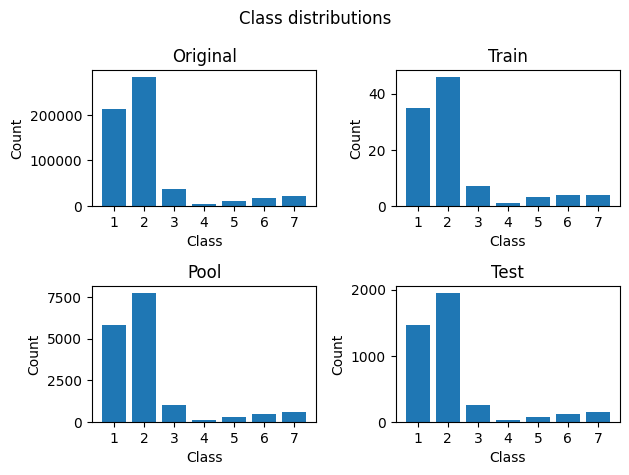

In [4]:
data,explained_var = prepare_data(
    cov_type,
    n_init=100,
    n_points=20000,   # optional (set None to use full dataset)
    seed=42,
    even_distribution=False
)
plot_downsampled_distribution(data)

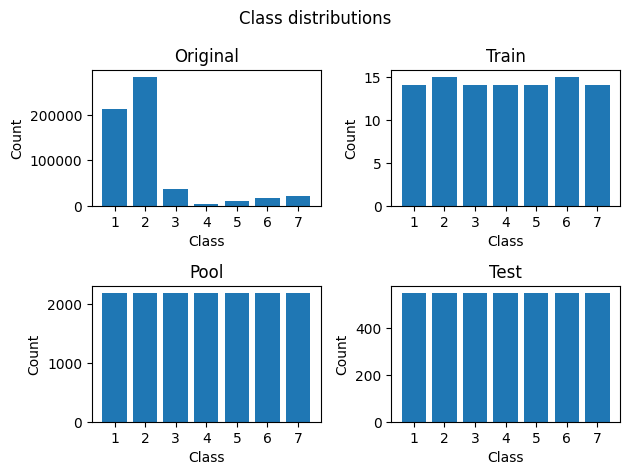

In [5]:
data,explained_var = prepare_data(
    cov_type,
    n_init=100,
    n_points=20000,   # optional (set None to use full dataset)
    seed=42,
    even_distribution=True
)

plot_downsampled_distribution(data)

# Train the model

In [15]:
data,explained_var = prepare_data(
    cov_type,
    n_init=14,
    n_points=20000,   # optional (set None to use full dataset)
    seed=42,
    even_distribution=True
)

model = LogisticRegression(solver='lbfgs', max_iter=400)

#test_acc_random = train_iteratively(data, model, "random", 20, 5)
test_acc_margin = train_iteratively(data, model, "margin", 3)

test_acc_margin

[(14, np.float64(0.28497139885595424)),
 (17, np.float64(0.23868954758190328)),
 (20, np.float64(0.2581903276131045)),
 (23, np.float64(0.31201248049922)),
 (26, np.float64(0.3172126885075403)),
 (29, np.float64(0.3205928237129485)),
 (32, np.float64(0.3247529901196048)),
 (35, np.float64(0.33125325013000523)),
 (38, np.float64(0.33177327093083725)),
 (41, np.float64(0.34763390535621425)),
 (44, np.float64(0.3611544461778471)),
 (47, np.float64(0.37285491419656785)),
 (50, np.float64(0.36037441497659906)),
 (53, np.float64(0.3608944357774311)),
 (56, np.float64(0.3699947997919917)),
 (59, np.float64(0.36973478939157567)),
 (62, np.float64(0.3798751950078003)),
 (65, np.float64(0.3858554342173687)),
 (68, np.float64(0.3879355174206968)),
 (71, np.float64(0.3876755070202808)),
 (74, np.float64(0.39391575663026523)),
 (77, np.float64(0.38559542381695266)),
 (80, np.float64(0.38637545501820075)),
 (83, np.float64(0.375455018200728)),
 (86, np.float64(0.36947477899115966))]